# ДЗ2, Часть 1. RAG, векторная база и память агента

Перенос эталонных функций семинара (`seminar02_skeleton_full.ipynb`) на свой корпус:
10 статей Habr/lawebbox из ДЗ1 вместо стартового набора статей Википедии. Тяжёлые шаги
(скрейпинг, полный замер на 73 вопросах, построение индекса) вынесены в отдельные
скрипты репозитория и запущены заранее — здесь они переиспользуются как модули, а
готовые результаты (таблицы, картинки) подгружаются и показываются.

Скрипты: `fetch_habr_corpus.py` → `build_questions_habr.py` → `build_index.py` →
`measure_rag.py` → `diagnose_failures.py` → `memory_demo.py`. Библиотека — `rag.py`
(чанкеры, эмбеддинги, Milvus, recall@k, RRF, rag_answer, знание-инструмент, память),
`agent.py` — ReAct-цикл и инструменты ДЗ1.

In [1]:
import json
from pathlib import Path

import pandas as pd
from IPython.display import Image, display

import agent as A
import rag as R

R.load_cache()
print("ключ есть:", bool(__import__("os").getenv("OPENROUTER_API_KEY")))
print("коллекции в Milvus:", R.get_client().list_collections())

ключ есть: True
коллекции в Milvus: ['facts', 'habr_chars', 'habr_lines']


## Шаг 1. Корпус и вопросы

Источники — `fetch_habr_corpus.py` (свой HTML-парсер на BeautifulSoup, MediaWiki-скрипт
семинара для Habr не подходит). Вопросы — `build_questions_habr.py`: 63 из 72 вопросов
ДЗ1 (9 дропнуто — цитаты не нашлись в статьях),
плюс 10 вопросов без ответа по теме корпуса.

In [2]:
corpus = R.load_corpus()
tasks = [json.loads(l) for l in Path("data/questions_habr.jsonl").read_text(encoding="utf-8").splitlines() if l.strip()]
print(f"страниц в корпусе: {len(corpus)}, символов: {sum(len(c['text']) for c in corpus)}")
print(f"вопросов: {len(tasks)} ({sum(t['answerable'] for t in tasks)} с ответом, {sum(not t['answerable'] for t in tasks)} без ответа)")
for c in corpus:
    print(f"  {c['page']:24s} {len(c['text']):7d} симв.  {c['url']}")

страниц в корпусе: 10, символов: 105799
вопросов: 73 (63 с ответом, 10 без ответа)
  Frontend Status #8         10900 симв.  https://habr.com/ru/articles/1009296/
  Frontend Status #7          8785 симв.  https://habr.com/ru/articles/1007014/
  Frontend Status #10         8554 симв.  https://habr.com/ru/articles/1015700/
  Frontend Status #15        12287 симв.  https://habr.com/ru/articles/1032276/
  Frontend Status #14         8695 симв.  https://habr.com/ru/articles/1028734/
  Frontend Status #18        16661 симв.  https://habr.com/ru/articles/1047986/
  Инженерная зрелость в JS    2222 симв.  https://lawebbox.com/articles/inzhenernaya-zrelost-v-js-pochemu/
  habr — статья про AI-агентов    6802 симв.  https://habr.com/ru/articles/1003526/
  Frontend Status #9         18294 симв.  https://habr.com/ru/articles/1012160/
  Frontend Status #11        12599 симв.  https://habr.com/ru/articles/1018828/


## Шаг 2. Индекс в Milvus и качество поиска

Две нарезки: наивная `chunk_chars` (300 символов) и осмысленная `chunk_sections`
(раздел дайджеста → метаданные, абзац/пункт → кусок). Обе индексируются в Milvus
(`docker-compose.yml`, метрика COSINE, коллекции `habr_chars`/`habr_lines`).

In [3]:
char_chunks = [c for p in corpus for c in R.chunk_chars(p)]
line_chunks = [c for p in corpus for c in R.chunk_sections(p)]
print(f"наивная нарезка: {len(char_chunks)} кусков (>= 300)")
print(f"осмысленная нарезка: {len(line_chunks)} кусков (>= 300)")

print("\nдемонстрация фильтра по странице:")
for h in R.search_milvus("habr_lines", "уязвимость безопасность", 3, 'page == "Frontend Status #8"'):
    print(" ", h["page"], "|", h["text"][:80])

наивная нарезка: 356 кусков (>= 300)
осмысленная нарезка: 368 кусков (>= 300)

демонстрация фильтра по странице:
  Frontend Status #8 | Крис Койер разбирает странную природу элемента <geolocation> — текст и иконку не
  Frontend Status #8 | Амит Шин разбирает, почему в крупных проектах z-index превращается в гонку воору
  Frontend Status #8 | В этом выпуске — CodePen 2.0 и клон Loom на Next.js в видео; про AI: почему колл


### Кривая recall@k (обе нарезки)

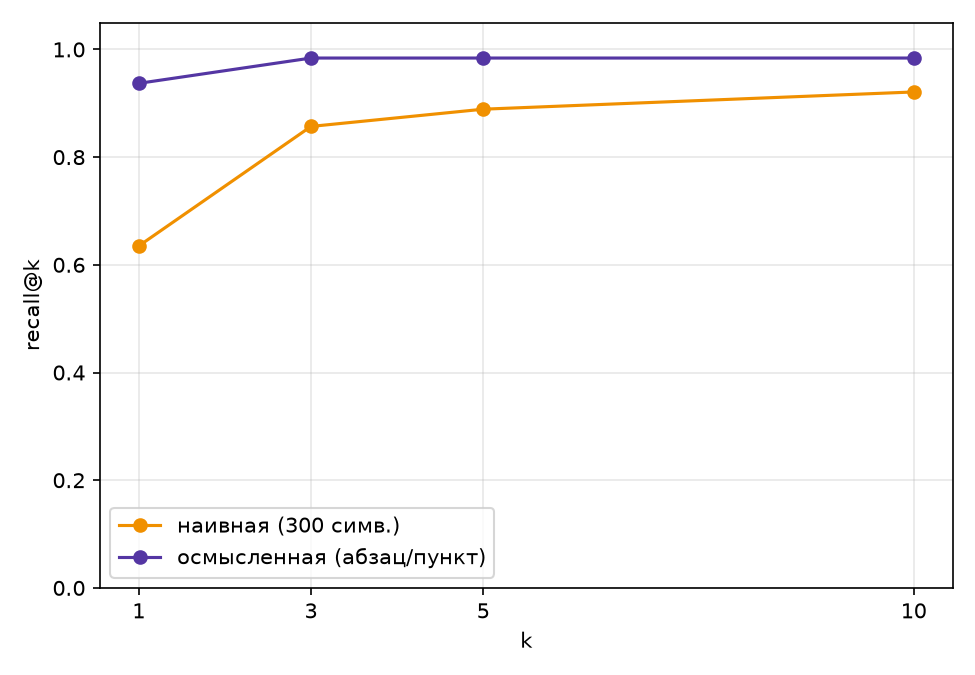

In [4]:
display(Image("img/recall.png"))

Наивная нарезка отстаёт уже на k=1 (0.635 против 0.937) — абзац Habr-дайджеста
несёт одну законченную мысль, а окно в 300 символов режет её пополам.
Выбран k=5: обе кривые к этому k на плато, а гибрид (ниже) на k=5 даёт 100% recall.

### Гибрид: вектор / слова / RRF (осмысленная нарезка)

In [5]:
hybrid_table = pd.read_csv("results_hybrid.csv")
hybrid_table

,k,вектор,слова,гибрид
0,1,0.937,0.794,0.952
1,3,0.984,0.937,0.968
2,5,0.984,0.952,1.000
3,10,0.984,0.968,1.000


## Шаг 3. RAG-ответ, инструмент агента и замер

`rag_answer` — прямой RAG-вызов; `knowledge_base` — тот же поиск, но как инструмент
агента (`agent.py`, `register`/`TOOLS`/`run_tool` из ДЗ1), модель сама решает, когда и
что искать. Обе используют контракт `FINAL: <ответ>` / `NOT_FOUND`.

In [6]:
demo_q = "Какой новый HTML-атрибут предложила команда Edge?"
r = R.rag_answer(demo_q, A.MODELS["cheap"], k=5)
print("rag_answer:", r["answer"])

run = R.kb_agent_run(demo_q, A.MODELS["cheap"])
print("\nagent + knowledge_base:")
A.show_trace(run)

rag_answer: Команда Edge предложила новый HTML-атрибут `focusgroup`, который обрабатывает клавиши стрелок, пропускает скрытые и отключенные элементы, учитывает направление текста и восстанавливает фокус при возврате [1]. 

FINAL: focusgroup.



agent + knowledge_base:
user     | Какой новый HTML-атрибут предложила команда Edge? 
assistant|  knowledge_base{"query":"новый HTML-атрибут команда Edge"}
tool     | [Frontend Status #8 / 🌎 Браузеры] Команда Edge предлагает новый HTML-атрибут focusgroup : добавляешь его на контейнер и браузер сам обрабатывает клавиши стрелок, пропускает скрытые 
assistant| Команда Edge предложила новый HTML-атрибут `focusgroup`. Он позволяет добавлять его на контейнер, и браузер сам обрабатывает клавиши стрелок, пропуская скрытые или отключенные элем 
шагов: 2, цена: 0.022 ¢, время: 3.7 c


### Итоговая таблица (measure_rag.py, все 63 вопроса с ответом)

In [7]:
import measure as M

results = pd.read_csv("results_rag.csv")
final_table = M.report(results[results["answerable"]])
final_table

,config,model,n,accuracy,cost_per_task,cost_per_correct,avg_steps,avg_seconds
0,"сильная, без инструментов",claude-sonnet-4.6,63,0.095,0.00256,0.02683,1.00,3.4
1,"дешёвая, живой поиск (ДЗ1)",gpt-4o-mini,63,0.413,0.00075,0.00183,4.41,11.6
2,"дешёвая, RAG всегда",gpt-4o-mini,63,0.746,0.00010,0.00014,1.00,1.4
3,"дешёвая, агент с knowledge_base",gpt-4o-mini,63,0.746,0.00022,0.00029,2.13,3.7
4,"средняя, RAG всегда",claude-haiku-4.5,63,0.825,0.00123,0.00149,1.00,2.1


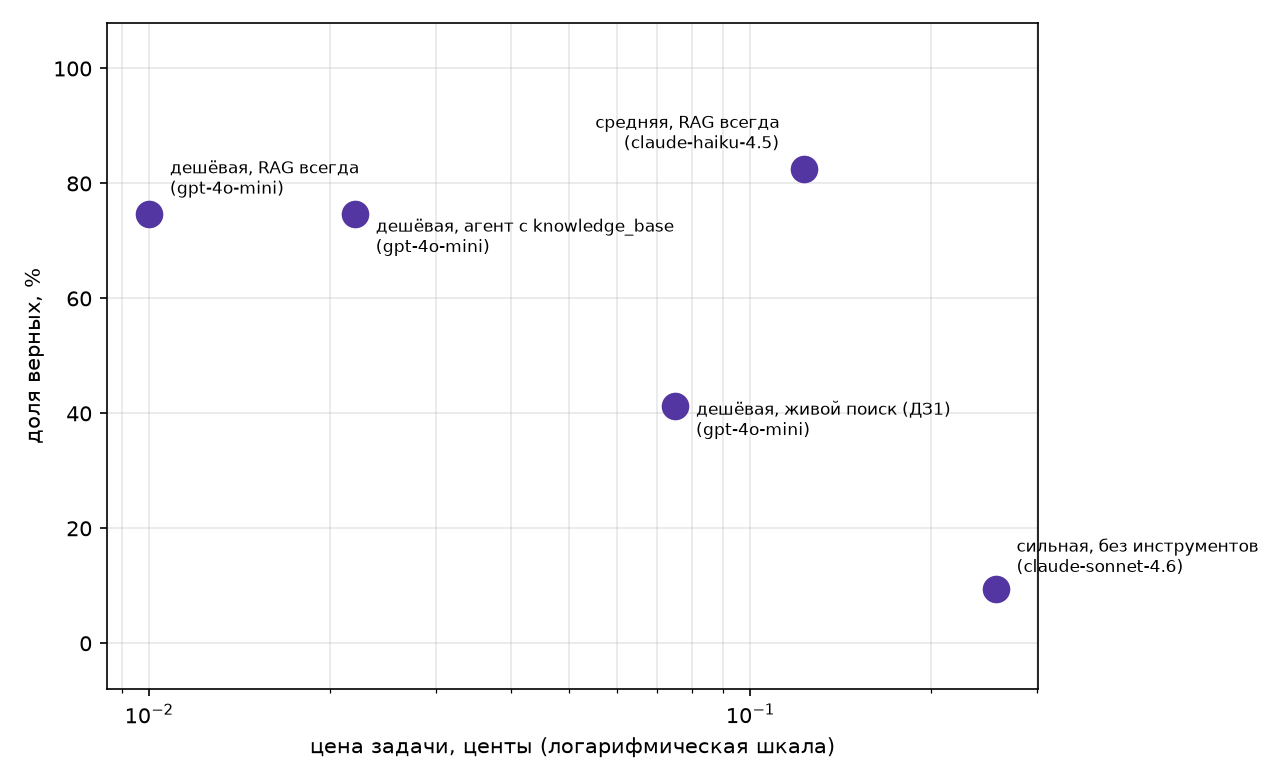

In [8]:
display(Image("img/money_rag.png"))

### Таблица отказов

In [9]:
pd.read_csv("results_refusals.csv")

,config,model,честно_отклонил_из_10,ложно_отклонил_из_answerable,answerable_n
0,"сильная, без инструментов",claude-sonnet-4.6,0,0,63
1,"дешёвая, живой поиск (ДЗ1)",gpt-4o-mini,0,0,63
2,"дешёвая, RAG всегда",gpt-4o-mini,10,10,63
3,"дешёвая, агент с knowledge_base",gpt-4o-mini,7,3,63
4,"средняя, RAG всегда",claude-haiku-4.5,1,2,63


### Два разобранных провала (лучшая конфигурация — см. вывод скрипта)

Полный разбор с текстом источников — в `diagnose_failures.py` и в README.md
(разделы «Два разобранных провала»). Коротко: «поиск не нашёл» — вопрос
`habr-48` сформулирован слишком общо, золотой кусок про WCAG 3 не попал в
top-5 по вектору (лечится гибридом/уточнением запроса); «нашёл, но неверно» —
`habr-4`, модель ответила по существу, но не дословно эталону, из-за чего
строгая проверка `is_correct` засчитала промах (лечится смягчением проверки
ответа или промптом «отвечай ближе к формулировке источника»).

## Шаг 4. Память

Эпизодическая — `episodes.jsonl` (журнал, не в контексте). Семантическая —
факты в Milvus-коллекции `facts` + `facts.json`, извлекаются дешёвой моделью
в конце сессии (`FACTS_SYSTEM` просит вернуть **полный** обновлённый список,
поэтому новый факт заменяет старый, а не дублируется).

In [2]:
import memory_demo as MD

MD.two_session_demo()

== сессия 1 ==
assistant: Привет, Макс! Команда Edge предложила новый HTML-атрибут `focusgroup`. Он позволяет добавлять его на контейнер, что упрощает обработку клавиш стрелок, пропускает скрытые и отключенные элементы, учитыв
факты после сессии 1: ['name: Макс', 'city: Калининград', 'job: фронтенд-разработчик', 'interests: хоккей']

== сессия 2 (история сессии 1 не в контексте) ==
assistant: Ты живешь в Калининграде и увлекаешься фронтенд-разработкой.

== пользователь меняет факт ==
assistant: Понял, ты теперь живешь в Санкт-Петербурге и увлекаешься футболом.
факты после сессии 2: ['name: Макс', 'city: Санкт-Петербург', 'job: фронтенд-разработчик', 'interests: футбол']


### График токенов: вся история vs окно + факты


вся история: 12 реплик, 10285 токенов на входе суммарно, $0.00175
окно+факты:  12 реплик, 7394 токенов на входе суммарно, $0.00133


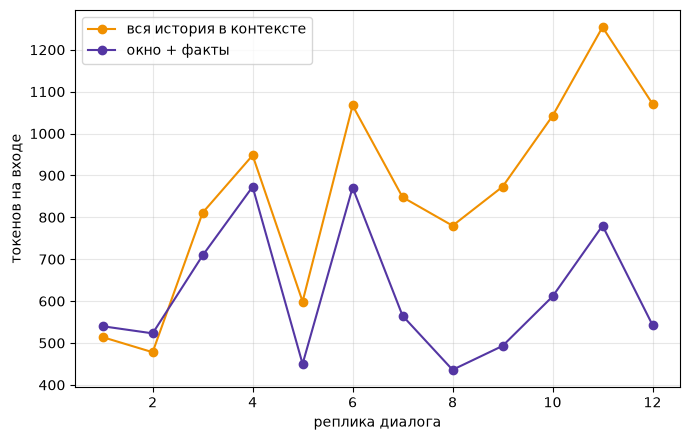

In [3]:
MD.token_chart(n_turns=12)

## Вывод

Полный текст — в README.md, раздел «Вывод». Коротко: RAG на дешёвой модели
бьёт сильную модель без инструментов в **190 раз** по цене верного ответа
(\$0.00014 против \$0.02683) и в **8 раз** по точности (74.6% против 9.5%) —
база знаний рядом оказалась не просто дешевле живого поиска ДЗ1, а на порядок
точнее (74.6% против 41.3%). Не всё однозначно: агент, сам решающий когда
искать, не обгоняет постоянный RAG по точности, но втрое честнее в отказах.